# Develop acceptance loop

In [1]:
import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

In [ ]:
from sklearn.ensemble import IsolationForest
import torch

from berebasl.simulation.credit_data_simulation import CreditDataGenerator, CreditData, CreditDataSample
from berebasl.simulation.acceptance_loop import accept_based_on_top_percentent_of_arbitrary_var
from berebasl.estimation.basl import BASLPartialUnbiaser
from berebasl.evaluation.batched_metrics import batched_auroc
from berebasl.evaluation.bayesian_evaluation import BayesianMetric
from berebasl.estimation.classifiers import TorchLogistic

In [ ]:
# Old sketch
if True:
    # Acceptance Loop

    stats: List[Dict[str, Union[float, int]]] = []
    models_state_dicts: List[Dict[str, Union[Dict[str, Any], str]]] = []

    for gen_nr in range(1, num_gens + 1):
        if gen_nr % 10 == 0:
            print("-- Iteration", f"{gen_nr}/{num_gens}:", credit_data.accepted_count, 
                "accepts and", credit_data.rejected_count, " rejects")
            
        ## Gather current statistics
        current_stats : dict = credit_data.data_stats()


        ## Get leakage-free data
        current_sample: CreditDataSample = credit_data.to_sample_dataset() # Ensure leakage-free data
        current_sample.manual_seed(initial_seed + gen_nr + 1) # internal rng handles seeds for splitting

        ## Accepts based scorecard
        ### Reset params to ensure no effect of last calculation
        classifier_accepts.reset_parameters_to_initial()
        classifier_accepts.fit(current_sample.features_labeled, current_sample.labels)

        classifier_accepts.eval()
        holdout_probs_bad_accepts_based = classifier_accepts.predict_proba(holdout_data.features)[..., 1]
        current_stats["auc_accepts"] = batched_auroc(holdout_probs_bad_accepts_based, holdout_data.default_flag).item()

        ## Oracle scorecard
        classifier_oracle.reset_parameters_to_initial()
        classifier_oracle.fit(credit_data.features, credit_data.default_flag) # Using explicitly all data

        classifier_oracle.eval()
        holdout_probs_bad_oracle = classifier_oracle.predict_proba(holdout_data.features)[..., 1]
        current_stats["auc_biased"] = batched_auroc(holdout_probs_bad_oracle, holdout_data.default_flag).item()

        ## Corrected scorecard
        augmented_sample: CreditDataSample = basl_unbiaser.basl_augment_sample(
            data=current_sample, 
            leave_orig_sample_untouched=True, 
            early_stop=True
        )
        basl_unbiaser.refit_model(which_one='strong', features=augmented_sample.features_labeled, labels=augmented_sample.labels)
        holdout_probs_basl = basl_unbiaser.predict_proba_model(which_one='strong', features=holdout_data.features)
        current_stats["auc_basl"] = batched_auroc(holdout_probs_basl, holdout_data.default_flag).item()

        stats.append(current_stats)

        if gen_nr == 1 or gen_nr % 10 == 0 or gen_nr == num_gens:
            models_state_dicts.append({
                "gen_round" : gen_nr,
                "accepts_model" : classifier_accepts.to_state_dict(),
                "oracle_model" : classifier_oracle.to_state_dict(),
                "basl_strong_model" : basl_unbiaser.strong_learner.to_state_dict()
            })

        if gen_nr < num_gens:
            ## Generate new data
            data_gen.manual_seed(initial_seed + gen_nr)
            # Let S:=sample_size
            feats_new_applicants, def_flag_new_applicants = data_gen.sample(sample_size, determinstic_mixture_weights) # [S, F], [S]
            with torch.no_grad():
                new_applicants_pred_def_probs = classifier_accepts.predict_proba(feats_new_applicants)[..., 1] # [S]
                new_applicants_accepted = new_applicants_pred_def_probs >= new_applicants_pred_def_probs.quantile(1-top_percent) # [S]

            max_accepts_allowed = round(sample_size*top_percent)
            currently_accepted = new_applicants_accepted.sum()
            if currently_accepted > max_accepts_allowed:
                count_to_flip = currently_accepted - max_accepts_allowed
                idx_accepted = torch.where(new_applicants_accepted)[0] # [currently_accepted,] 
                perm = torch.randperm(currently_accepted, generator=data_gen.rng, device=data_gen.device) 
                idx_to_flip = idx_accepted[perm[:count_to_flip]]
                new_applicants_accepted[idx_to_flip] = False
                
            credit_data.add_gen(feats_new_applicants, def_flag_new_applicants, new_applicants_accepted)
            

        break


## Checking reproducibility

Two simulations were generated with the same arguments on the same machine - only different amount of processors involved. They should therefore
contain pretty much the same data at the end.

In [33]:
sim_parent_dir = "../berebasl/data/simulations"
simulation_dirs = ['default_sim', 'replicate_default']

simulation_results = {}

for sim_dir in simulation_dirs:
    results_path = os.path.join(sim_parent_dir, sim_dir, "simulation_results.pt")
    simulation_results[sim_dir] = torch.load(results_path, map_location='cpu', weights_only=False)

In [34]:
sim1, sim2 = simulation_dirs
results_check = {}

def compare_credit_data(credit_data1: CreditData, credit_data2: CreditData) -> dict:
    if credit_data2.features.shape != credit_data1.features.shape:
        raise AssertionError("Features shape do not match, comparision not possible")
    results = {}

    results["features"] = {
        "all_equal" : torch.all(credit_data1.features==credit_data2.features).item(),
        "all_close" : torch.allclose(credit_data1.features, credit_data2.features)
    }

    results["gen_round_equal"] = torch.all(credit_data1.gen_round == credit_data2.gen_round).item()
    results["label_equal"] = torch.all(credit_data1.default_flag == credit_data2.default_flag).item()
    results["accepted_equal"] = torch.all(credit_data1.accepted == credit_data2.accepted).item()

    return results

compare_credit_data(simulation_results[sim1]["credit_data"], simulation_results[sim2]["credit_data"])

{'features': {'all_equal': True, 'all_close': True},
 'gen_round_equal': True,
 'label_equal': True,
 'accepted_equal': True}

## Acceptance loop based on CV-Rule

### Discussion on which metric base the statistic on

As a CV-Rule the Kolmogorov-Smirnov (KS) statistic is chosen as a natural option
which
- Does not require any assumption on profit-structure, which avoids further
  assumptions on the DGP
- As it is based on discriminatory power given some threshold it relates conceptually
  to the AU-ROC and every other rank based statistic and
- It can be calculated in a vectorized manner.

<!---From here on it is a copy paste from Claude--->

The statistic measures the maximum separation between two cumulative distribution functions. 
In binary classification, we compare the distributions of predicted scores for the positive 
class (e.g., defaulters) versus the negative class (e.g., non-defaulters).

#### Mathematical definition of the KS-Statistic for the binary classification case

Given a set of predictions with scores $(s_i)_{i \in \{1, \ldots, n\}}$ and binary labels
$y_i \in \{0,1\}$. Define
- $F_+$ as the empirical CDF of scores for positive samples ($y_i=1$)
- $F_{-}$ empirical CDF of scores for negative samples ($y_i=0$)

The empirical CDFs are defined as
$$
F_+(t) := \frac{1}{P} \sum_{i=1}^n I(s_i \leq t) \cdot I(y_i = 1)
$$
$$
F_-(t) := \frac{1}{N} \sum_{i=1}^n I(s_i \leq t) \cdot I(y_i = 0)
$$
where $P := \sum_{i=1}^n y_i$ the total number of positives and $N = n - P$ the total
number of negatives. The **KS statistic** is then defined as
$$
KS = \max_t \left| F_+(t) - F_-(t) \right|
$$

meaning it find

In [2]:
import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

In [ ]:
import time
from typing import Union, Tuple, Optional

from berebasl.utils.tensor_validation import assert_tensors
from berebasl.simulation.acceptance_loop import default_dgp
from berebasl.evaluation.k_fold_validation import k_fold_cv_normalized_split, train_folds_from_cv_folds
from berebasl.evaluation.batched_metrics import batched_roc_points, batched_ks_statistic
from berebasl.simulation.credit_data_simulation import CreditDataGenerator, GaussianMixture
from berebasl.estimation.classifiers import BatchedLogistic

from scipy.stats import ks_2samp


import torch

torch.set_num_threads(16)
try:
    torch.set_num_interop_threads(4)
except RuntimeError as e:
    interop_threads_already_set_msg = (
        "Error: cannot set number of interop threads after "
        "parallel work has started or set_num_interop_threads called"
    ) 
    if str(e) !=interop_threads_already_set_msg:
        raise(e)


In [ ]:
device=torch.device('cpu')
dtype=torch.float32

B=256

dgp = default_dgp(
    seed_credit_data_gen=1807,
    deterministic_weights_for_mixture_sampling=True,
    device=device,
    dtype=dtype
)
batched_dgp = CreditDataGenerator(
    **{
        g_b : GaussianMixture(
            mean=getattr(dgp, g_b).mean.expand(B,-1),
            cov=getattr(dgp, g_b).cov.expand(B, -1, -1)
        )
        for g_b in ("bad_mixture", "good_mixture")
    },
    noise_var=dgp.noise_std**2,
    bad_ratio=dgp.bad_ratio,
    seed=1807,
    deterministic_weight_sampling=dgp.determinstic_mixture_weights
)

feats, targets = batched_dgp.sample(int(2**14)) # [B, N, F], [B, N]
mask = torch.bernoulli( # [B, N]
    torch.full_like(targets, 0.85),
    generator=batched_dgp.rng
).to(bool)
targets.masked_fill_(~mask, value=-1)
feats.masked_fill_(~mask.unsqueeze(-1), value=float('nan'))

cv_feats, cv_lbls, cv_mask = k_fold_cv_normalized_split( # [B, K, n_k, F], [B, K, n_k], [B, K, n_k]
    feats,
    targets,
    rng=dgp.rng,
    k=10,
    nan_lbls=-1
)
train_feats, train_lbls, train_mask = train_folds_from_cv_folds(cv_feats, cv_lbls, cv_mask, make_contiguous=True)

In [4]:
batched_lr = BatchedLogistic(
    n_features=dgp.features_count,
    batch_shape=train_lbls.shape[:-1],
    device=device
)
count_models_to_trian = torch.tensor(train_lbls.shape[:-1]).prod().item()
print("Starting to train", count_models_to_trian, "models")
begin_training = time.time()
batched_lr.fit(train_feats, train_lbls, train_mask)
train_time = time.time() - begin_training

print("Time needed in total:", round(train_time,2), "s. Averaging:", round(train_time/count_models_to_trian, 2), "s/model")

Starting to train 2560 models
Time needed in total: 35.7 s. Averaging: 0.01 s/model


In [5]:
batched_lr.eval()
cv_scores = batched_lr.predict_proba(cv_feats)[..., 1]
## Batched
dim=-1
max_ks, ks_thresholds = batched_ks_statistic(
    cv_scores,
    cv_lbls,
    cv_mask,
    dim=dim,
    return_thresholds=True,
    keepdim=False
)

## scipy
ks_stats_scipy = []

for fold_scores, fold_lbls, fold_mask in zip(
    *[ten.flatten(0, -2) for ten in (cv_scores, cv_lbls, cv_mask)]
):
    # Extract valid entries
    valid_scores = fold_scores[fold_mask].detach().cpu().numpy()
    valid_labels = fold_lbls[fold_mask].detach().cpu().numpy()
    
    # Separate scores by class
    scores_pos = valid_scores[valid_labels == 1]  # Defaulters
    scores_neg = valid_scores[valid_labels == 0]  # Non-defaulters
    
    # Two-sample KS test
    ks_stat = ks_2samp(scores_pos, scores_neg, alternative='two-sided').statistic
    ks_stats_scipy.append(ks_stat)

ks_stats_scipy = torch.tensor(ks_stats_scipy).reshape(max_ks.shape).to(ks_thresholds.dtype)

# Compare
abs_diffs = torch.abs(max_ks - ks_stats_scipy)
print("Max absolute difference:", abs_diffs.max().item())
print("Mean absolute difference:", abs_diffs.mean().item())
print("Relative error:", (abs_diffs / (ks_stats_scipy + 1e-8)).mean().item())

# Should be very close (within floating point precision)
assert torch.allclose(max_ks, ks_stats_scipy, atol=1e-5, rtol=1e-4), \
    "KS statistics don't match!"

Max absolute difference: 5.960464477539063e-08
Mean absolute difference: 1.550652051207635e-08
Relative error: 2.0765286379287318e-08


## Making the Acceptance loop based on automatically selected threshold

In [2]:
import torch

from berebasl.estimation.classifiers import BatchedLogistic
from berebasl.simulation.acceptance_loop import default_dgp
from berebasl.evaluation.k_fold_validation import k_fold_cv_normalized_split, train_folds_from_cv_folds
from berebasl.evaluation.batched_metrics import batched_ks_statistic

device=torch.device('cpu')
dtype=torch.float32

B=256

dgp = default_dgp(
    seed_credit_data_gen=1807,
    deterministic_weights_for_mixture_sampling=True,
    device=device,
    dtype=dtype
)

In [3]:
unb_feats, unb_lbls = dgp.sample(10_000)
acc_flag=torch.bernoulli(torch.full_like(unb_lbls, 0.3), generator=dgp.rng).to(bool)

In [ ]:
from typing import Dict, Tuple
from berebasl.evaluation.batched_metrics import batched_roc_points, optimal_roc_thresholds_from_roc_points, batched_auroc_from_roc_points
from berebasl.utils.normalized_shape_tensor_ops import masked_batched_trapz

def batched_cv_evaluation(
        scores_cv: torch.Tensor,
        lbls_cv: torch.Tensor,
        mask_cv: torch.Tensor,
) -> Dict[str, Tuple[torch.Tensor, torch.Tensor]]:
    dim = -1
    cv_ks_values, cv_ks_thresholds = batched_ks_statistic(
        scores_cv,
        lbls_cv,
        mask_cv,
        dim,
        return_thresholds=True
    )
    
    fpr, tpr, sorted_scores, _, sorted_mask_valid = batched_roc_points(
        scores_cv,
        lbls_cv,
        mask_cv,
        dim
    )

    cv_aurocs = batched_auroc_from_roc_points(
        fpr, tpr, sorted_scores, sorted_mask_valid, dim, keepdim=False
    )
    cv_roc_thresholds = optimal_roc_thresholds_from_roc_points(
        fpr, tpr, sorted_scores, sorted_mask_valid, dim, keepdim=False
    )


    return {
        "ks" : (cv_ks_values, cv_ks_thresholds),
        "roc" : (cv_aurocs, cv_roc_thresholds)
    }

def logit_val_scores(
        train_feats: torch.Tensor,
        train_lbls: torch.Tensor,
        train_mask: torch.Tensor,
        val_feats: torch.Tensor
) -> torch.Tensor:
    batched_lr = BatchedLogistic(
        n_features=train_feats.size(-1),
        batch_shape=train_lbls.shape[:-1],
        device=unb_feats.device,
        dtype=unb_feats.dtype
    )

    batched_lr.fit(train_feats, train_lbls, train_mask)

    val_scores = batched_lr.predict_proba(val_feats)[..., -1]
    return val_scores

def realistic_oracle_ks_exp(
        unb_feats: torch.Tensor,
        unb_lbls: torch.Tensor,
        acc_flag: torch.Tensor,
        k_folds: int,
        min_per_fold: int,
        cv_count: int,
        rng: torch.Generator = None
) -> torch.Tensor:
    # This function manages only partly batched input
    feats_acc = unb_feats[acc_flag].unsqueeze(0).repeat(cv_count, 1, 1)
    lbls_acc = unb_lbls[acc_flag].unsqueeze(0).repeat(cv_count, 1)
    _, N_acc, F = feats_acc.shape # on N_acc we do the vali, that's why we take it
    effective_k_folds = min(N_acc // min_per_fold, k_folds)

    feats_acc_cv, lbls_acc_cv, mask_valid_acc_cv = k_fold_cv_normalized_split(
        feats_acc,
        lbls_acc,
        rng=rng,
        k=effective_k_folds
    )
    rej_flag = ~acc_flag
    feats_rej = unb_feats[rej_flag].unsqueeze(0).repeat(cv_count, 1, 1)
    lbls_rej = unb_lbls[rej_flag].unsqueeze(0).repeat(cv_count, 1, )
    feats_rej_cv, lbls_rej_cv, mask_valid_rej_cv = k_fold_cv_normalized_split(
        feats_rej,
        lbls_rej,
        rng=rng,
        k=effective_k_folds
    )
    cat_dim = lbls_rej_cv.dim()-1

    train_feats, train_lbls, train_mask = [
        torch.cat([acc, rej], dim=cat_dim).contiguous()
        for acc, rej in zip(
            train_folds_from_cv_folds(feats_acc_cv, lbls_acc_cv, mask_valid_acc_cv),
            train_folds_from_cv_folds(feats_rej_cv, lbls_rej_cv, mask_valid_rej_cv)
        )
    ]

    scores_acc_cv = logit_val_scores(
        train_feats, train_lbls, train_mask, feats_acc_cv
    )

    return batched_cv_evaluation(scores_acc_cv, lbls_acc_cv, mask_valid_acc_cv)

realistic_oracle_ks_exp(unb_feats, unb_lbls, acc_flag, dgp.rng, 5, 128, 10)

{'ks': (tensor([[0.7084, 0.7687, 0.7039, 0.7679, 0.7439],
          [0.7195, 0.7602, 0.7249, 0.7428, 0.7380],
          [0.7394, 0.7566, 0.7378, 0.7321, 0.7198],
          [0.7458, 0.7623, 0.6819, 0.7369, 0.7555],
          [0.7566, 0.6874, 0.7288, 0.7503, 0.7402],
          [0.7347, 0.6962, 0.7231, 0.7466, 0.7694],
          [0.7374, 0.7660, 0.7341, 0.7307, 0.7127],
          [0.7433, 0.7229, 0.7068, 0.7605, 0.7450],
          [0.7137, 0.7438, 0.7325, 0.7312, 0.7422],
          [0.7519, 0.7532, 0.7450, 0.7423, 0.7120]]),
  tensor([[0.5258, 0.5917, 0.5734, 0.6026, 0.3891],
          [0.5666, 0.6127, 0.3948, 0.5854, 0.6050],
          [0.6150, 0.4210, 0.6033, 0.3297, 0.4291],
          [0.4567, 0.6076, 0.5159, 0.3313, 0.5284],
          [0.6458, 0.5218, 0.5119, 0.6188, 0.5820],
          [0.5984, 0.2892, 0.4233, 0.6263, 0.6752],
          [0.4018, 0.4848, 0.5991, 0.5954, 0.6125],
          [0.4578, 0.5964, 0.5596, 0.5105, 0.5636],
          [0.3836, 0.6170, 0.6185, 0.5877, 0.4631],
    

## Make reporting for the CreditDataGenerator

In [5]:
from itertools import combinations


for n in range(3, 7):
    print(list(combinations(range(n), 2)))

[(0, 1), (0, 2), (1, 2)]
[(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
[(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]


In [6]:
import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from berebasl.simulation.credit_data_simulation import CreditDataGenerator, GaussianMixture

from IPython.display import Markdown, display
import numpy as np
from matplotlib import colormaps
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse
import torch

dtype = torch.float32
device = torch.device('cpu')

from typing import Any, Callable, Dict, List, Literal, Optional, Union, Tuple

def make_plot_dicts_to_show_dgp(
        data_gen: CreditDataGenerator, 
        sample_size: int, 
        cmap_dict: Optional[Dict[str, Callable[[int], Tuple[float, float, float]]]]
    ) -> Union[List[Dict[str, List[Dict[str, Any]]]]]:
    sampled_feats, sampled_labels, sampled_K_idxs = data_gen.sample(sample_size, reveal_mixture_components=True)

    gb_vals = ["bad", "good"]
    plot_dicts = [{gb: [] for gb in gb_vals} for _ in range(data_gen.B)]

    is_batched = data_gen.is_batched
    is_mixture: Dict[str, bool] = {gb : getattr(data_gen, gb+'_mixture').is_mixture for gb in gb_vals}
    is_mixture["any"] = any(is_mixture.values())
    noise_var = data_gen.noise_std ** 2

    mixtures_K: Dict[str, Optional[int]] = {gb: getattr(data_gen, gb+'_mixture').K if is_mixture[gb] else None for gb in gb_vals}

    gm_params = sum([
        [gm.mean, gm.effective_cov_additive(noise_var) if data_gen.add_noise else gm.cov] 
        for gm in (data_gen.good_mixture, data_gen.bad_mixture)
    ], [])

    batch_iter = (
        (feats, lbls, K_idxs, gm_bad_mean, gm_bad_cov, gm_good_mean, gm_good_cov)
        for feats, lbls, K_idxs, gm_bad_mean, gm_bad_cov, gm_good_mean, gm_good_cov
        in (
            zip(
                sampled_feats, 
                sampled_labels, 
                sampled_K_idxs if is_mixture["any"] else [None]*data_gen.B, 
                *gm_params
            )
            if is_batched else
            [(
                sampled_feats, 
                sampled_labels, 
                sampled_K_idxs, 
                *gm_params
            )]
        )
    )
    for b, (B_feats, B_lbls, B_K_idxs, B_gm_bad_mean, B_gm_bad_cov, B_gm_good_mean, B_gm_good_cov) in enumerate(batch_iter):
        plot_dict = plot_dicts[b]
        batch_add_suffix = f"^{{b={b}}}" if is_batched else ""
        for gb in gb_vals:
            gb_add_suffix = gb[0] + batch_add_suffix
            for k in range(mixtures_K[gb]) if is_mixture[gb] else [0]:
                mask = B_lbls == data_gen.bad_good_encoding[gb]
                mean, cov = (B_gm_bad_mean, B_gm_bad_cov) if gb=="bad" else (B_gm_good_mean, B_gm_good_cov)
                if is_mixture[gb]:
                    mask &= B_K_idxs == k
                    mean, cov = [p[k] for p in (mean, cov)]
                    suffix = gb_add_suffix + "_{k=" + str(k) + '}'
                else:
                    suffix = gb_add_suffix

                plot_dict[gb].append({
                    "sample": B_feats[mask],
                    "mixture_mean": mean,
                    "mixture_cov": cov,
                    "color": cmap_dict[gb](k),
                    "label_suffix": suffix
                })
    if not is_batched:
        plot_dicts = plot_dicts[0]

    return plot_dicts

def plot_cov_ellipse(mean, cov, ax, color_alpha: float = 0.2):
    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort eigenvalues (largest first for consistency)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Compute angle (in degrees) of the ellipse
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    # Width and height = 2 * sqrt(eigenvalues)
    # (factor 2 because matplotlib expects full width, not radius)
    width, height = 2 * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor=(0,0,0,color_alpha),  # Semi-transparent black
        facecolor='none',
        linewidth=1.5,
        zorder = 10.0
    )

    ax.add_patch(ellipse)

def plot_population_sample(
        sample: torch.Tensor,
        mixture_mean: torch.Tensor,
        mixture_cov: torch.Tensor,
        color: Tuple[int, int, int],
        label_suffix: str,
        ax: plt.Axes = None,
        transparency_alpha: float = 0.08
) -> None:
    if ax is None:
        ax = plt.gca()

    ax.scatter(sample[:,0], sample[:,1], s=5, color=color + (transparency_alpha,), marker='o')
    ax.scatter(mixture_mean[0].item(), mixture_mean[1].item(), s=20, color = color,
                facecolor='white', edgecolor=color,
                label=f"$\\mathbb{{E}}\\,[X_{{{label_suffix}}}]$", zorder = 10.0)
    plot_cov_ellipse(
        mixture_mean.cpu().numpy(), 
        mixture_cov.cpu().numpy(),
        ax
    )

def place_legend_below_axis(
    ax: plt.Axes,
    ncol: Optional[int] = None,
    y_offset: float = -0.18,
    fontsize: int = 9
):
    """
    Places a wide, row-wise legend below the x-axis.

    Parameters
    ----------
    ax : plt.Axes
    ncol : number of columns (defaults to all entries in one row)
    y_offset : vertical offset (negative -> below axis)
    fontsize : legend font size
    """
    handles, labels = ax.get_legend_handles_labels()

    if not handles:
        return

    # Default: make it as wide as possible (single row)
    if ncol is None:
        ncol = len(handles)

    ax.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, y_offset),
        ncol=ncol,
        frameon=False,
        fontsize=fontsize,
        handlelength=1.5,
        columnspacing=1.2
    )

def plot_dgp(
        data_gen: CreditDataGenerator, 
        sample_size: int, 
        cmap_dict: Optional[Dict[str, Callable[[int], Tuple[float, float, float]]]] = None,
        axes: Optional[List[plt.Axes]] = None,
        plotting_order = ["good", "bad"],
        transparency_alpha = 0.08,
        legend_y_offset = -0.09,
        legend_modus: Literal['none', 'below', 'default'] = "below"
    ) -> None:
    if cmap_dict is None:
        if max(data_gen.good_mixture.K, data_gen.bad_mixture.K) > 5:
            raise AssertionError("Too many mixtures - plotting only possible by passing cmap_dict, also consider using other method")
        tab10_good_bad_idxs = {
            "bad" : [1, 3, 4, 5, 7],
            "good" : [0, 2, 6, 8, 9]
        }

        cmap_dict: Dict[str, Callable[[int], Tuple[float, float, float]]] = {
            "bad" : lambda idx : colormaps["tab10"](tab10_good_bad_idxs["bad"][idx])[:3],
            "good" : lambda idx : colormaps["tab10"](tab10_good_bad_idxs["good"][idx])[:3]
        }
    
    plot_dicts = make_plot_dicts_to_show_dgp(data_gen, sample_size, cmap_dict)
    is_batched = data_gen.is_batched
    B = data_gen.B

    if not is_batched:
        plot_dicts = [plot_dicts]


    for b, plot_dict_list, ax in zip(range(B), plot_dicts, [None]*len(plot_dicts) if axes is None else axes):
        if ax is None:
            ax = plt.gca()
        for current_key in plotting_order:
            for plot_dict in plot_dict_list[current_key]:
                plot_population_sample(ax=ax, transparency_alpha=transparency_alpha, **plot_dict)

            ax.set_title(
                "Visualization of " + " and ".join(
                    [f"$X_{{{k[0]}}}" + (f"^{{B={b}}}" if is_batched else "")+ '$' 
                    for k in plotting_order]
                    )
            )
            ax.set_xlabel("$x_1$")
            ax.set_ylabel("$x_2$")
            place_legend_below_axis(
                ax,
                ncol = max(max(data_gen.good_mixture.K, round((data_gen.good_mixture.K + data_gen.bad_mixture.K)/2)), 4) if data_gen.good_mixture.is_mixture else None,
                y_offset=legend_y_offset
            )
            #ax.legend()

        if axes is None:
            plt.show()


In [10]:
cmap_dict = None
if True:
    if cmap_dict is None:
        if max(data_gen.good_mixture.K, data_gen.bad_mixture.K) > 5:
            raise AssertionError("Too many mixtures - plotting only possible by passing cmap_dict, also consider using other method")
        tab10_good_bad_idxs = {
            "bad" : [1, 3, 4, 5, 7],
            "good" : [0, 2, 6, 8, 9]
        }

        cmap_dict: Dict[str, Callable[[int], Tuple[float, float, float]]] = {
            "bad" : lambda idx : colormaps["tab10"](tab10_good_bad_idxs["bad"][idx])[:3],
            "good" : lambda idx : colormaps["tab10"](tab10_good_bad_idxs["good"][idx])[:3]
        }

In [11]:
sample_size = 20_000
if True:
    sampled_feats, sampled_labels, sampled_K_idxs = data_gen.sample(sample_size, reveal_mixture_components=True)

    gb_vals = ["bad", "good"]
    plot_dicts = [{gb: [] for gb in gb_vals} for _ in range(data_gen.B)]

    is_batched = data_gen.is_batched
    is_mixture: Dict[str, bool] = {gb : getattr(data_gen, gb+'_mixture').is_mixture for gb in gb_vals}
    is_mixture["any"] = any(is_mixture.values())
    noise_var = data_gen.noise_std ** 2

    mixtures_K: Dict[str, Optional[int]] = {gb: getattr(data_gen, gb+'_mixture').K if is_mixture[gb] else None for gb in gb_vals}

    gm_params = sum([
        [gm.mean, gm.effective_cov_additive(noise_var) if data_gen.add_noise else gm.cov] 
        for gm in (data_gen.good_mixture, data_gen.bad_mixture)
    ], [])

    batch_iter = (
        (feats, lbls, K_idxs, gm_bad_mean, gm_bad_cov, gm_good_mean, gm_good_cov)
        for feats, lbls, K_idxs, gm_bad_mean, gm_bad_cov, gm_good_mean, gm_good_cov
        in (
            zip(
                sampled_feats, 
                sampled_labels, 
                sampled_K_idxs if is_mixture["any"] else [None]*data_gen.B, 
                *gm_params
            )
            if is_batched else
            [(
                sampled_feats, 
                sampled_labels, 
                sampled_K_idxs, 
                *gm_params
            )]
        )
    )
    for b, (B_feats, B_lbls, B_K_idxs, B_gm_bad_mean, B_gm_bad_cov, B_gm_good_mean, B_gm_good_cov) in enumerate(batch_iter):
        plot_dict = plot_dicts[b]
        batch_add_suffix = f"^{{b={b}}}" if is_batched else ""
        for gb in gb_vals:
            gb_add_suffix = gb[0] + batch_add_suffix
            for k in range(mixtures_K[gb]) if is_mixture[gb] else [0]:
                mask = B_lbls == data_gen.bad_good_encoding[gb]
                mean, cov = (B_gm_bad_mean, B_gm_bad_cov) if gb=="bad" else (B_gm_good_mean, B_gm_good_cov)
                if is_mixture[gb]:
                    mask &= B_K_idxs == k
                    mean, cov = [p[k] for p in (mean, cov)]
                    suffix = gb_add_suffix + "_{k=" + str(k) + '}'
                else:
                    suffix = gb_add_suffix

                plot_dict[gb].append({
                    "sample": B_feats[mask],
                    "mixture_mean": mean,
                    "mixture_cov": cov,
                    "color": cmap_dict[gb](k),
                    "label_suffix": suffix
                })

#### Single Gaussian

The credit data DGP contains no noise and samples with a bad ratio of 16.6%.It's bayes error rate is 7.12%. The bad and good populations are defined as follows:

The bads represent 16.6% of the data and its covariates' DGP is a Gaussian Distribution characterized by:

$$
X_{b} \sim\mathcal{N}\left(\mu_{b} = \begin{bmatrix}
	3.0\\
	5.0
\end{bmatrix}, \Sigma_{b} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right)
$$



The goods represent 83.4% of the data and its covariates' DGP is a Gaussian Distribution characterized by:

$$
X_{g} \sim\mathcal{N}\left(\mu_{g} = \begin{bmatrix}
	4.8\\
	6.8
\end{bmatrix}, \Sigma_{g} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right)
$$





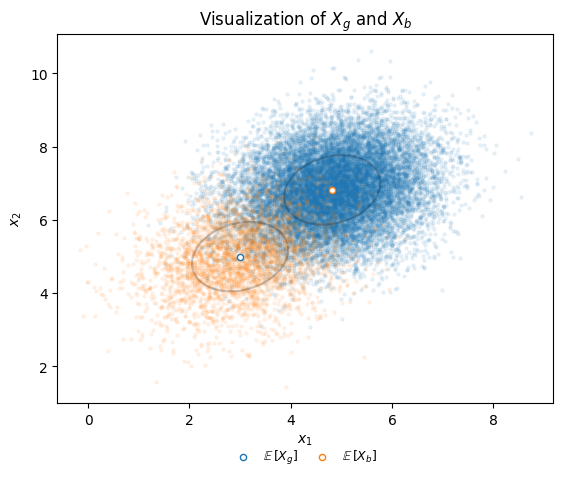

#### Batched Gaussians

The credit data DGP contains no noise and samples with a bad ratio of 33.3%. The bad and good populations are defined as follows:

The bads represent 33.3% of the data and its covariates' DGP is a batched (b=2)Gaussian Distribution characterized by:

**Batch 0**: Bayes error rate is 6.32%
$$
X_{b} \sim\mathcal{N}\left(\mu_{b} = \begin{bmatrix}
	3.0\\
	5.0
\end{bmatrix}, \Sigma_{b} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right)
$$

**Batch 1**: Bayes error rate is 6.17%
$$
X_{b} \sim\mathcal{N}\left(\mu_{b} = \begin{bmatrix}
	2.0\\
	3.0
\end{bmatrix}, \Sigma_{b} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right)
$$

The goods represent 66.7% of the data and its covariates' DGP is a batched (b=2)Gaussian Distribution characterized by:

**Batch 0**: Bayes error rate is 6.32%
$$
X_{g} \sim\mathcal{N}\left(\mu_{g} = \begin{bmatrix}
	5.2\\
	7.2
\end{bmatrix}, \Sigma_{g} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right)
$$

**Batch 1**: Bayes error rate is 6.17%
$$
X_{g} \sim\mathcal{N}\left(\mu_{g} = \begin{bmatrix}
	4.2\\
	5.2
\end{bmatrix}, \Sigma_{g} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right)
$$



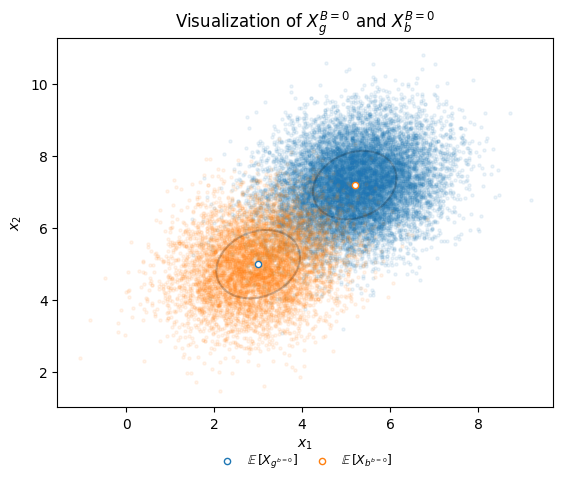

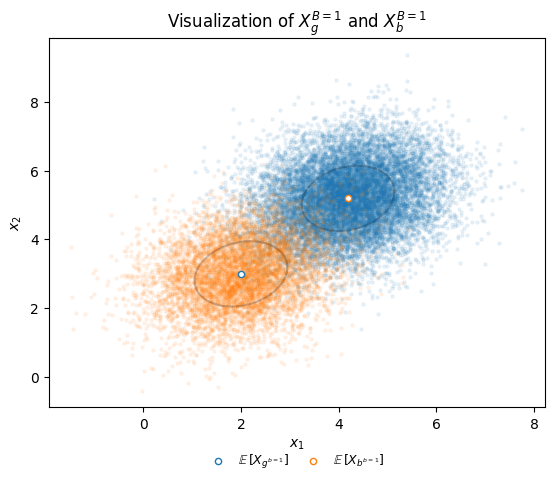

#### Gaussian Mixture

The credit data DGP contains no noise and samples with a bad ratio of 35.2%.It's bayes error rate is 16.22%. The bad and good populations are defined as follows:

The bads represent 35.2% of the data and its covariates' DGP is a Gaussian Mixture with random weights characterized by:

$$
X_{b} \mid \{Z = k \}  \sim \mathcal{N}\left(\mu_{b_{k}}, \Sigma_{b_{k}}\right), \, Z \sim \text{{Categorical}}\left(\pi_{1}=0.50, \pi_{2}=0.50\right)
$$
with
$$
X_{b_{1}} \sim\mathcal{N}\left(\mu_{b_{1}} = \begin{bmatrix}
	3.0\\
	5.0
\end{bmatrix}, \Sigma_{b_{1}} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right), \;X_{b_{2}} \sim\mathcal{N}\left(\mu_{b_{2}} = \begin{bmatrix}
	2.0\\
	4.0
\end{bmatrix}, \Sigma_{b_{2}} = \begin{bmatrix}
	1.0 & 0.3\\
	0.3 & 1.0
\end{bmatrix}\right)
$$



The goods represent 64.8% of the data and its covariates' DGP is a Gaussian Mixture with random weights characterized by:

$$
X_{g} \mid \{Z = k \}  \sim \mathcal{N}\left(\mu_{g_{k}}, \Sigma_{g_{k}}\right), \, Z \sim \text{{Categorical}}\left(\pi_{1}=0.50, \pi_{2}=0.50\right)
$$
with
$$
X_{g_{1}} \sim\mathcal{N}\left(\mu_{g_{1}} = \begin{bmatrix}
	4.8\\
	6.8
\end{bmatrix}, \Sigma_{g_{1}} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right), \;X_{g_{2}} \sim\mathcal{N}\left(\mu_{g_{2}} = \begin{bmatrix}
	3.8\\
	5.8
\end{bmatrix}, \Sigma_{g_{2}} = \begin{bmatrix}
	1.0 & 0.3\\
	0.3 & 1.0
\end{bmatrix}\right)
$$





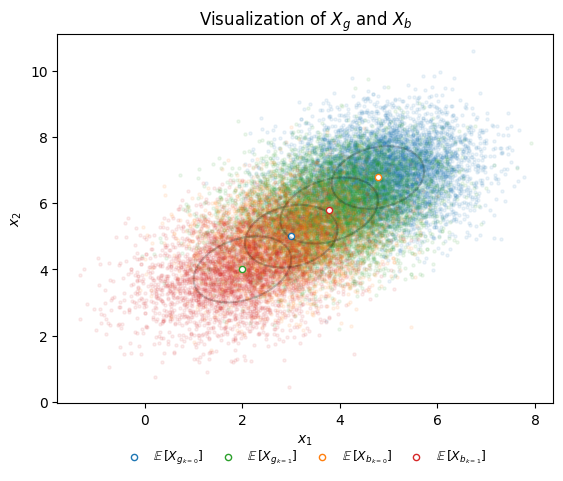

#### Batched Gaussian Mixture

The credit data DGP contains no noise and samples with a bad ratio of 54.8%. The bad and good populations are defined as follows:

The bads represent 54.8% of the data and its covariates' DGP is a batched (b=2)Gaussian Mixture with random weights characterized by:

**Batch 0**: Bayes error rate is 19.54%
$$
X_{b} \mid \{Z = k \}  \sim \mathcal{N}\left(\mu_{b_{k}}, \Sigma_{b_{k}}\right), \, Z \sim \text{{Categorical}}\left(\pi_{1}=0.50, \pi_{2}=0.50\right)
$$
with
$$
X_{b_{1}} \sim\mathcal{N}\left(\mu_{b_{1}} = \begin{bmatrix}
	3.0\\
	5.0
\end{bmatrix}, \Sigma_{b_{1}} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right), \;X_{b_{2}} \sim\mathcal{N}\left(\mu_{b_{2}} = \begin{bmatrix}
	2.0\\
	4.0
\end{bmatrix}, \Sigma_{b_{2}} = \begin{bmatrix}
	1.0 & 0.3\\
	0.3 & 1.0
\end{bmatrix}\right)
$$

**Batch 1**: Bayes error rate is 19.41%
$$
X_{b} \mid \{Z = k \}  \sim \mathcal{N}\left(\mu_{b_{k}}, \Sigma_{b_{k}}\right), \, Z \sim \text{{Categorical}}\left(\pi_{1}=0.50, \pi_{2}=0.50\right)
$$
with
$$
X_{b_{1}} \sim\mathcal{N}\left(\mu_{b_{1}} = \begin{bmatrix}
	2.0\\
	3.0
\end{bmatrix}, \Sigma_{b_{1}} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right), \;X_{b_{2}} \sim\mathcal{N}\left(\mu_{b_{2}} = \begin{bmatrix}
	1.0\\
	2.0
\end{bmatrix}, \Sigma_{b_{2}} = \begin{bmatrix}
	1.0 & 0.3\\
	0.3 & 1.0
\end{bmatrix}\right)
$$

The goods represent 45.2% of the data and its covariates' DGP is a batched (b=2)Gaussian Mixture with random weights characterized by:

**Batch 0**: Bayes error rate is 19.54%
$$
X_{g} \mid \{Z = k \}  \sim \mathcal{N}\left(\mu_{g_{k}}, \Sigma_{g_{k}}\right), \, Z \sim \text{{Categorical}}\left(\pi_{1}=0.50, \pi_{2}=0.50\right)
$$
with
$$
X_{g_{1}} \sim\mathcal{N}\left(\mu_{g_{1}} = \begin{bmatrix}
	4.6\\
	6.6
\end{bmatrix}, \Sigma_{g_{1}} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right), \;X_{g_{2}} \sim\mathcal{N}\left(\mu_{g_{2}} = \begin{bmatrix}
	3.6\\
	5.6
\end{bmatrix}, \Sigma_{g_{2}} = \begin{bmatrix}
	1.0 & 0.3\\
	0.3 & 1.0
\end{bmatrix}\right)
$$

**Batch 1**: Bayes error rate is 19.41%
$$
X_{g} \mid \{Z = k \}  \sim \mathcal{N}\left(\mu_{g_{k}}, \Sigma_{g_{k}}\right), \, Z \sim \text{{Categorical}}\left(\pi_{1}=0.50, \pi_{2}=0.50\right)
$$
with
$$
X_{g_{1}} \sim\mathcal{N}\left(\mu_{g_{1}} = \begin{bmatrix}
	3.6\\
	4.6
\end{bmatrix}, \Sigma_{g_{1}} = \begin{bmatrix}
	0.9 & 0.2\\
	0.2 & 0.9
\end{bmatrix}\right), \;X_{g_{2}} \sim\mathcal{N}\left(\mu_{g_{2}} = \begin{bmatrix}
	2.6\\
	3.6
\end{bmatrix}, \Sigma_{g_{2}} = \begin{bmatrix}
	1.0 & 0.3\\
	0.3 & 1.0
\end{bmatrix}\right)
$$



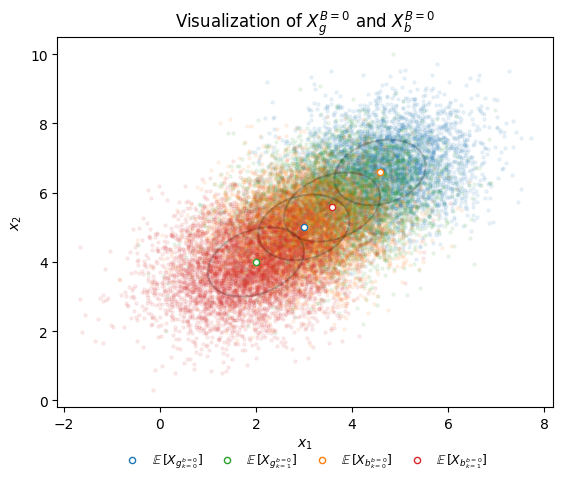

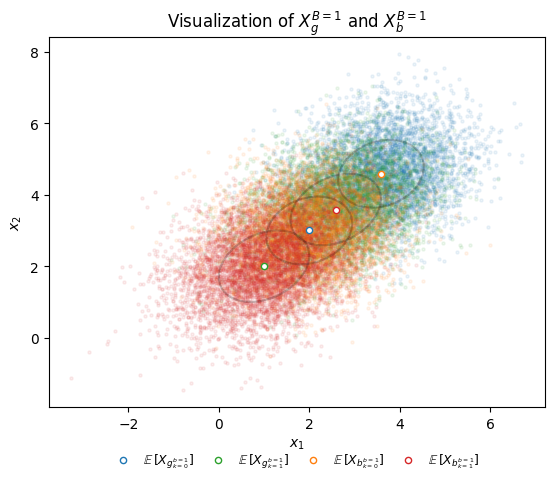

In [7]:
from copy import deepcopy

full_mean = torch.tensor([[1.0, 2.0]], dtype=dtype, device=device).unsqueeze(0).repeat(2, 2, 1)
full_mean[0] *= 2
full_mean[:, 0] += 1

full_cov = torch.tensor(   
        [
            [
                [ 1.0,   0.2], 
                [ 0.2,   1.0]
            ],
            [
                [ 1.0 ,  0.3], 
                [ 0.3 ,  1.0]
            ]
        ], 
        dtype=dtype, device=device
    ).unsqueeze(0)

full_cov[:, 0] *= 0.9

full_weights = torch.tensor([0.5, 0.5], dtype=dtype, device=device).unsqueeze(0)

possible_cases = [
    "Single Gaussian",
    "Batched Gaussians",
    "Gaussian Mixture",
    "Batched Gaussian Mixture"
]

for case in possible_cases:
    if case == "Single Gaussian":
        gm = GaussianMixture(
            mean=full_mean[0, 0],
            cov=full_cov[0, 0],
            weights=None,
            check_params=True
        )
    elif case == "Batched Gaussians":
        gm = GaussianMixture(
            mean=full_mean[:, 0],
            cov=full_cov[:, 0],
            weights=None,
            check_params=True
        )
    elif case == "Gaussian Mixture":
        gm = GaussianMixture(
            mean=full_mean[0],
            cov=full_cov[0],
            weights=full_weights[0],
            check_params=True
        )
    elif case == "Batched Gaussian Mixture":
        gm = GaussianMixture(
            mean=full_mean,
            cov=full_cov,
            weights=full_weights,
            check_params=True
        )

    data_gen = CreditDataGenerator(
        bad_mixture=gm,
        good_mixture=deepcopy(gm),
        noise_var=0.0,
        bad_ratio=torch.rand([]).item() / 2 + 0.1,
        seed=1807
    )

    data_gen.good_mixture.mean += (torch.randn([]).item() + 2) # / 2


    display(Markdown(f"#### {case}"))
    display(Markdown(data_gen.dgp_tex_report()))
    plot_dgp(data_gen, sample_size=20_000)
    print("\n\n")

In [43]:
import numpy as np
from matplotlib import colormaps
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse
from typing import Tuple
from berebasl.simulation.gaussian_mixture import GaussianMixture

def plot_cov_ellipse(mean, cov, ax, color_alpha: float = 0.2):
    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort eigenvalues (largest first for consistency)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Compute angle (in degrees) of the ellipse
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    # Width and height = 2 * sqrt(eigenvalues)
    # (factor 2 because matplotlib expects full width, not radius)
    width, height = 2 * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor=(0,0,0,color_alpha),  # Semi-transparent black
        facecolor='none',
        linewidth=1.5
    )

    ax.add_patch(ellipse)

def plot_population_sample(
        sample: torch.Tensor,
        mixture_mean: torch.Tensor,
        mixture_cov: torch.Tensor,
        color: Tuple[int, int, int],
        label_suffix: str,
        ax: plt.Axes = None,
        transparency_alpha: float = 0.08
) -> None:
    if ax is None:
        ax = plt.gca()

    ax.scatter(sample[:,0], sample[:,1], s=5, color=color + (transparency_alpha,), marker='o')
    ax.scatter(mixture_mean[0].item(), mixture_mean[1].item(), s=20, color = color,
                facecolor='white', edgecolor=color,
                label=f"$\\mathbb{{E}}\\,[X_{{{label_suffix}}}]$")
    plot_cov_ellipse(
        mixture_mean.cpu().numpy(), 
        mixture_cov.cpu().numpy(),
        ax
    )

## Making the acceptance loop have three variables, one of them being latent

In [12]:
import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from berebasl.simulation.credit_data_simulation import CreditDataGenerator, GaussianMixture

from IPython.display import Markdown, display
import torch

dtype = torch.float32
device = torch.device('cpu')

dgp = CreditDataGenerator.init_with_internal_logic(
        count_covariates=3,
        mean_bad_diff=torch.tensor([1.0, 2.0, -1.0], dtype=dtype, device=device),
        covars = {
            "bad" : torch.tensor(
                [
                    [1.0,   0.2, -0.1], 
                    [0.2,   1.0, -0.1], 
                    [-0.1, -0.1,  1.0]
                ], 
                dtype=dtype, device=device
            ),
            "good" : torch.tensor(
                [
                    [ 1.0, -0.2, 0.1], 
                    [-0.2,  1.0, 0.1],
                    [ 0.1,  0.1, 1.0]
                ], 
                dtype=dtype, device=device
            )
        },
        iid = False,
        mixture_weights=None,
        bad_ratio = 0.5,
        noise_var=0.0,
        device = device,
        dtype=dtype,
        seed_credit_data_gen=1807,
        deterministic_weights_for_mixture_sampling = False
    )


display(Markdown(dgp.dgp_tex_report()))


The credit data DGP contains no noise and samples with a bad ratio of 50.0%.It's bayes error rate is 10.69%. The bad and good populations are defined as follows:

The bads represent 50.0% of the data and its covariates' DGP is a Gaussian Distribution characterized by:

$$
X_{b} \sim\mathcal{N}\left(\mu_{b} = \begin{bmatrix}
	0.0\\
	0.0\\
	0.0
\end{bmatrix}, \Sigma_{b} = \begin{bmatrix}
	1.0 & 0.2 & -0.1\\
	0.2 & 1.0 & -0.1\\
	-0.1 & -0.1 & 1.0
\end{bmatrix}\right)
$$



The goods represent 50.0% of the data and its covariates' DGP is a Gaussian Distribution characterized by:

$$
X_{g} \sim\mathcal{N}\left(\mu_{g} = \begin{bmatrix}
	1.0\\
	2.0\\
	-1.0
\end{bmatrix}, \Sigma_{g} = \begin{bmatrix}
	1.0 & -0.2 & 0.1\\
	-0.2 & 1.0 & 0.1\\
	0.1 & 0.1 & 1.0
\end{bmatrix}\right)
$$





In [16]:
dgp.good_mixture.cov

tensor([[ 1.0000, -0.2000,  0.1000],
        [-0.2000,  1.0000,  0.1000],
        [ 0.1000,  0.1000,  1.0000]])

In [14]:
X, y = dgp.sample(1_000_000)